# 체크포인트 검증

In [1]:
import torch
from torch.utils.data import DataLoader
from pytorch_lightning import Trainer, seed_everything

seed_everything(42)

Global seed set to 42


42

In [2]:
# config, Dataset, DataLoader 재생성 
from data import CharucoDataset
from configs import load_configuration

CONFIG_PATH = 'config.yaml'
config = load_configuration(CONFIG_PATH)
val_dataset = CharucoDataset(config, config.val_labels, config.val_images, visualize=False, validation=True)
val_loader = DataLoader(val_dataset, batch_size=config.bs_val, shuffle=False, num_workers=0, pin_memory=True)

Using Transformation with negative_p=0.05, refinenet=False, seed=42


In [3]:
# 모델 아키텍쳐 준비  (학습때랑 동일하게)

from models.net import lModel, dcModel

n_ids = (config.row_count - 1) * (config.col_count - 1)
init_kwargs = dict(
    dcModel=dcModel(n_ids=n_ids)
)

In [4]:
# 체크포인트 선택

ckpt_path = "lightning_logs/version_28/checkpoints/epoch=4-step=18485.ckpt"

model = lModel.load_from_checkpoint(ckpt_path, **init_kwargs)

trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    limit_val_batches=0,
    detect_anomaly=True,
    precision="bf16",
    num_sanity_val_steps=0
)

results = trainer.validate(model, dataloaders=val_loader)


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:67: UserWarning: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
  warning_cache.warn(
You are using a CUDA device ('NVIDIA GeForce RTX 3080 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more detail

In [9]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
print("len(val_dataset) =", len(val_dataset))
print("len(val_loader)  =", len(val_loader))
# 한 배치 뽑아보기
batch = next(iter(val_loader), None)
print("first batch is None? ->", batch is None)


len(val_dataset) = 5000
len(val_loader)  = 79
Processing image 000000397133.jpg with idx 0
Processing image 000000037777.jpg with idx 1
Processing image 000000252219.jpg with idx 2
Processing image 000000087038.jpg with idx 3
Processing image 000000174482.jpg with idx 4
Processing image 000000403385.jpg with idx 5
Processing image 000000006818.jpg with idx 6
Processing image 000000480985.jpg with idx 7
Processing image 000000458054.jpg with idx 8
Processing image 000000331352.jpg with idx 9
Processing image 000000296649.jpg with idx 10
Processing image 000000386912.jpg with idx 11
Processing image 000000502136.jpg with idx 12
Processing image 000000491497.jpg with idx 13
Processing image 000000184791.jpg with idx 14
Processing image 000000348881.jpg with idx 15
Processing image 000000289393.jpg with idx 16
Processing image 000000522713.jpg with idx 17
Processing image 000000181666.jpg with idx 18
Processing image 000000017627.jpg with idx 19
Processing image 000000143931.jpg with idx 2

In [10]:
import pandas as pd
df = pd.read_csv('lightning_logs/version_28/metrics.csv')
print(df.columns)

Index(['train_loss_loc', 'train_loss_ids', 'train_loss', 'epoch', 'step'], dtype='object')


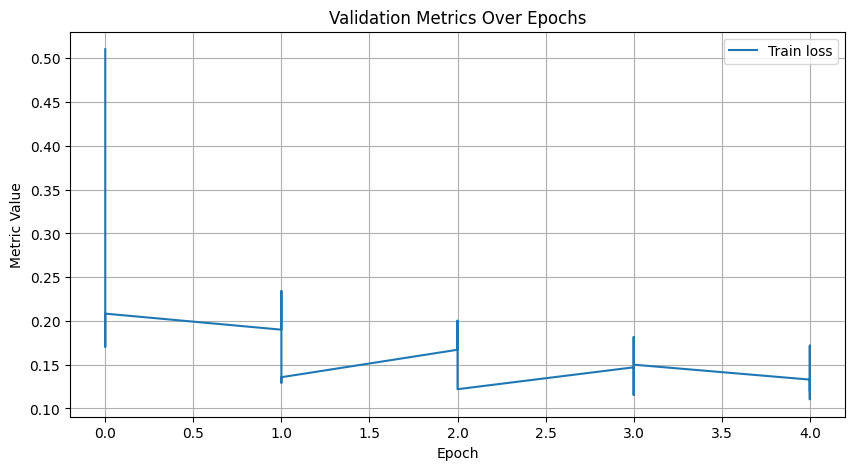

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 불러오기
metrics = pd.read_csv("lightning_logs/version_28/metrics.csv")

# step이나 epoch 기준으로 필요한 지표만 선택
# 'epoch'가 NaN인 행은 step 단위 로그일 수 있으니 제거
metrics = metrics.dropna(subset=["epoch"])

# 예시: val_loss, val_match_ratio 시각화
plt.figure(figsize=(10, 5))
plt.plot(metrics["epoch"], metrics["train_loss"], label="Train loss")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Validation Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()
